# Efficient Video Captioning using Adaptive Semantic-Motion Keyframe Selection

**MSVD + BLIP-2 research workflow.** This Colab-compatible notebook implements reproducible video-level splits, frame-selection ablations, T4-conscious LoRA fine-tuning, test-set-safe tuning, automatic evaluation, and artifact tracking. Set the paths in Section 0, run the smoke test, then enable the full experiments deliberately.


# 0. Research Configuration


In [ ]:
from dataclasses import dataclass, asdict
from pathlib import Path
import os, json, random, time, gc, math, warnings

@dataclass
class ResearchConfig:
    # Set these three values only when configuring a new MSVD location.
    DATA_ROOT: str = "/content/msvd"
    VIDEO_DIR: str = "YouTubeClips"
    CAPTION_FILE: str = "captions.csv"
    OUTPUT_DIR: str = "/content/video_captioning_outputs"
    SEED: int = 42
    NUM_CANDIDATE_FRAMES: int = 30
    NUM_SELECTED_FRAMES: int = 8
    ALPHA: float = 0.50
    MIN_TEMPORAL_DISTANCE: float = 0.50  # seconds
    IMAGE_SIZE: int = 224
    BATCH_SIZE: int = 1
    GRADIENT_ACCUMULATION_STEPS: int = 8
    LEARNING_RATE: float = 1e-4
    NUM_EPOCHS: int = 3
    MAX_CAPTION_LENGTH: int = 32
    NUM_WORKERS: int = 2
    MODEL_NAME: str = "Salesforce/blip2-opt-2.7b"
    TRAIN_RATIO: float = 0.80
    VAL_RATIO: float = 0.10
    TEST_RATIO: float = 0.10
    USE_LORA: bool = True
    USE_4BIT: bool = False  # enable only if bitsandbytes is available and necessary
    SMOKE_TEST_VIDEOS: int = 4
    MAX_TRAIN_VIDEOS: int | None = None  # e.g. 100 for a fast pilot
    RUN_FULL_METADATA: bool = False
    RUN_FINETUNING: bool = False
    RUN_TEST_ABLATIONS: bool = False
    RUN_FRAME_BUDGET_STUDY: bool = False

CFG = ResearchConfig()
ROOT = Path(CFG.DATA_ROOT)
VIDEO_ROOT = ROOT / CFG.VIDEO_DIR
CAPTION_PATH = ROOT / CFG.CAPTION_FILE
OUT = Path(CFG.OUTPUT_DIR)
ARTIFACT_DIRS = ["results/figures", "results/metrics", "results/generated_captions",
                 "results/frame_scores", "results/qualitative", "results/logs",
                 "checkpoints/uniform_baseline", "checkpoints/proposed", "configs", "cache"]
for relative in ARTIFACT_DIRS:
    (OUT / relative).mkdir(parents=True, exist_ok=True)
with open(OUT / "configs/experiment_config.json", "w") as f:
    json.dump(asdict(CFG), f, indent=2)
print(json.dumps(asdict(CFG), indent=2))


{
  "DATA_ROOT": "/content/msvd",
  "VIDEO_DIR": "YouTubeClips",
  "CAPTION_FILE": "captions.csv",
  "OUTPUT_DIR": "/content/video_captioning_outputs",
  "SEED": 42,
  "NUM_CANDIDATE_FRAMES": 30,
  "NUM_SELECTED_FRAMES": 8,
  "ALPHA": 0.5,
  "MIN_TEMPORAL_DISTANCE": 0.5,
  "IMAGE_SIZE": 224,
  "BATCH_SIZE": 1,
  "GRADIENT_ACCUMULATION_STEPS": 8,
  "LEARNING_RATE": 0.0001,
  "NUM_EPOCHS": 3,
  "MAX_CAPTION_LENGTH": 32,
  "NUM_WORKERS": 2,
  "MODEL_NAME": "Salesforce/blip2-opt-2.7b",
  "TRAIN_RATIO": 0.8,
  "VAL_RATIO": 0.1,
  "TEST_RATIO": 0.1,
  "USE_LORA": true,
  "USE_4BIT": false,
  "SMOKE_TEST_VIDEOS": 4,
  "MAX_TRAIN_VIDEOS": null,
  "RUN_FULL_METADATA": false,
  "RUN_FINETUNING": false,
  "RUN_TEST_ABLATIONS": false,
  "RUN_FRAME_BUDGET_STUDY": false
}


# 1. Environment and GPU Setup


In [ ]:
# Optional Drive mount: it is never forced, and local /content data works unchanged.
MOUNT_GOOGLE_DRIVE = False
if MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")


In [ ]:
import importlib.util, subprocess, sys
required = {"transformers":"transformers==4.45.2", "accelerate":"accelerate==0.34.2", "peft":"peft==0.12.0",
            "cv2":"opencv-python-headless==4.10.0.84", "rouge_score":"rouge-score==0.1.2", "evaluate":"evaluate==0.4.3",
            "wordcloud":"wordcloud==1.9.3", "sentencepiece":"sentencepiece==0.2.0", "nltk":"nltk==3.9.1"}
missing = [spec for module, spec in required.items() if importlib.util.find_spec(module) is None]
print("Missing packages:", missing or "none")
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import torch, numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
from IPython.display import display
warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(CFG.SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU name: {torch.cuda.get_device_name(0)}\nGPU memory: {props.total_memory/2**30:.2f} GB")
else: print("GPU name: CPU (CUDA unavailable)\nGPU memory: n/a")
print(f"CUDA available: {torch.cuda.is_available()}\nPyTorch: {torch.__version__}")
print("OpenCV:", cv2.__version__)


Missing packages: ['rouge-score==0.1.2', 'evaluate==0.4.3']
GPU name: Tesla T4
GPU memory: 14.56 GB
CUDA available: True
PyTorch: 2.11.0+cu128
OpenCV: 5.0.0


# 2. Dataset Loading and Verification


In [ ]:
import kagglehub, shutil

def ensure_msvd(root: Path):
    """Populate ROOT with captions + video clips if not already present. Idempotent."""
    if (root / CFG.VIDEO_DIR).exists() and any(root.rglob("*.csv")):
        return
    caption_src = Path(kagglehub.dataset_download("vtrnanh/msvd-dataset-corpus"))
    video_src = Path(kagglehub.dataset_download("sarthakjain004/msvd-clips"))  # confirm this matches your actual clips source

    root.mkdir(parents=True, exist_ok=True)
    csv_path = next(caption_src.rglob("*.csv"))
    shutil.copy(csv_path, root / CFG.CAPTION_FILE)

    video_dst = root / CFG.VIDEO_DIR
    video_dst.mkdir(parents=True, exist_ok=True)
    for ext in ("*.avi", "*.mp4", "*.webm", "*.mov"):
        for f in video_src.rglob(ext):
            shutil.copy(f, video_dst / f.name)
    print(f"Captions: {csv_path.name} | Videos copied: {len(list(video_dst.iterdir()))}")

def discover_caption_file(root: Path, configured: Path) -> Path:
    if configured.exists():
        return configured
    choices = list(root.rglob("*.csv")) + list(root.rglob("*.json")) + list(root.rglob("*.tsv"))
    captionish = [p for p in choices if any(s in p.name.lower() for s in ("caption", "description", "annotation"))]
    if captionish:
        print("Configured caption file not found; discovered:", captionish[0])
        return captionish[0]
    raise FileNotFoundError(f"Caption file absent: {configured}. Set CFG.CAPTION_FILE in Section 0.")

def read_caption_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".json":
        raw = json.load(open(path))
        return pd.json_normalize(raw if isinstance(raw, list) else raw.get("data", raw))
    return pd.read_csv(path, sep="\t" if path.suffix.lower() == ".tsv" else ",", engine="python")

def normalize_captions(raw: pd.DataFrame) -> pd.DataFrame:
    """Map common MSVD schemas to video_id/caption while retaining provenance fields.

    Raw MSVD video_corpus.csv stores VideoID as the bare YouTube ID (e.g. '-pUwIypksfE'),
    NOT the trimmed-clip filename. Clip files are named VideoID_Start_End.ext, so when
    Start/End columns exist we must rebuild the composite ID before it can ever join
    against video_paths — otherwise every row silently ends up unmatched.
    """
    lookup = {str(c).strip().lower().replace(" ", "_").replace("-", "_"): c for c in raw.columns}
    def pick(options): return next((lookup[x] for x in options if x in lookup), None)

    id_col = pick(["video_id", "video", "video_name", "videoid", "clip_id", "filename", "file_name"])
    caption_col = pick(["caption", "description", "sentence", "text", "caption_text"])
    start_col, end_col = pick(["start"]), pick(["end"])
    if not id_col or not caption_col:
        raise ValueError(f"Cannot map video/caption columns. Found {list(raw.columns)}; edit normalize_captions().")

    out = raw.copy().rename(columns={id_col: "video_id", caption_col: "caption"})
    if start_col and end_col:
        out["video_id"] = (out["video_id"].astype(str).str.strip() + "_" +
                            out[start_col].astype(str).str.strip() + "_" +
                            out[end_col].astype(str).str.strip())
    else:
        out["video_id"] = out.video_id.astype(str).str.strip().str.replace(
            r"\.(avi|mp4|webm|mov)$", "", regex=True, case=False)
    out["caption"] = out.caption.astype(str).str.strip()
    return out[out.caption.ne("") & out.video_id.ne("")].reset_index(drop=True)

ensure_msvd(ROOT)
CAPTION_PATH = discover_caption_file(ROOT, CAPTION_PATH)
raw_captions = read_caption_table(CAPTION_PATH)
captions = normalize_captions(raw_captions)

video_extensions = {".avi", ".mp4", ".webm", ".mov", ".mkv"}
video_paths = {p.stem: p for p in VIDEO_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in video_extensions} if VIDEO_ROOT.exists() else {}
caption_ids, file_ids = set(captions.video_id), set(video_paths)

print("Caption file path:", CAPTION_PATH, "\nVideo directory:", VIDEO_ROOT)
print("Video files:", len(video_paths), "Caption records:", len(captions))
print("Missing video count:", len(caption_ids - file_ids), "Missing caption count:", len(file_ids - caption_ids))
if caption_ids and file_ids and not (caption_ids & file_ids):
    print("WARNING: zero overlap between caption IDs and video filenames — check ID format:")
    print("  sample caption ids:", list(caption_ids)[:3])
    print("  sample video ids:  ", list(file_ids)[:3])

display(raw_captions.head()); print("Raw shape:", raw_captions.shape); display(raw_captions.dtypes)
display(raw_captions.isna().sum().to_frame("missing")); print("Duplicate raw rows:", raw_captions.duplicated().sum())
print("Unique captioned videos:", captions.video_id.nunique()); display(captions.head())

100%|██████████| 3.09M/3.09M [00:01<00:00, 2.47MB/s]

Extracting files...


100%|██████████| 1.71G/1.71G [01:29<00:00, 20.6MB/s]

Extracting files...


Captions: video_corpus.csv | Videos copied: 1970
Caption file path: /content/msvd/captions.csv 
Video directory: /content/msvd/YouTubeClips
Video files: 1970 Caption records: 122604
Missing video count: 119 Missing caption count: 1


...

Raw shape: (122604, 8)


,0
VideoID,object
Start,int64
End,int64
WorkerID,int64
Source,object
AnnotationTime,int64
Language,object
Description,object


,missing
VideoID,0
Start,0
End,0
WorkerID,0
Source,0
AnnotationTime,0
Language,0
Description,1


Duplicate raw rows: 28
Unique captioned videos: 2088


,video_id,Start,End,WorkerID,Source,AnnotationTime,Language,caption
0,mv89psg6zh4_33_46,33,46,588702,unverified,55,Slovene,Papagaj se umiva pod tekočo vodo v lijaku.
1,mv89psg6zh4_33_46,33,46,588702,unverified,37,Slovene,Papagaj se umiva pod tekočo vodo v lijaku.
2,mv89psg6zh4_33_46,33,46,362812,unverified,11,Macedonian,папагал се бања
3,mv89psg6zh4_33_46,33,46,968828,unverified,84,German,Ein Wellensittich duscht unter einem Wasserhahn.
4,mv89psg6zh4_33_46,33,46,203142,unverified,14,Romanian,o pasare sta intr-o chiuveta.


# 3. Exploratory Data Analysis


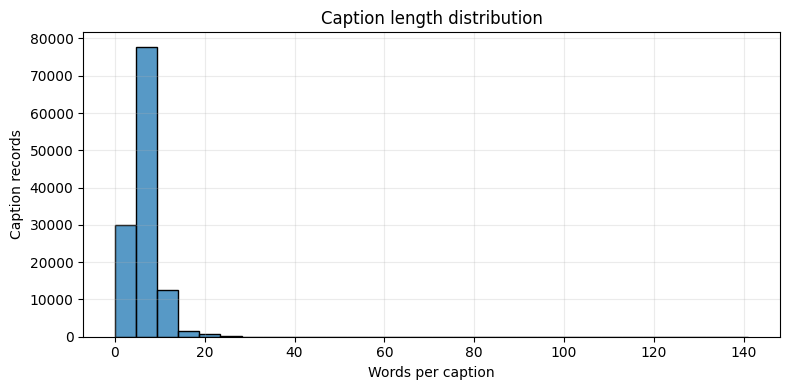

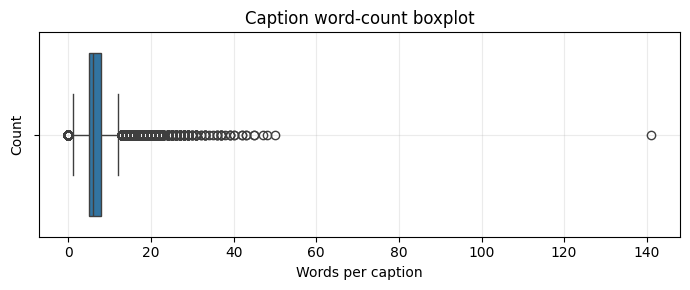

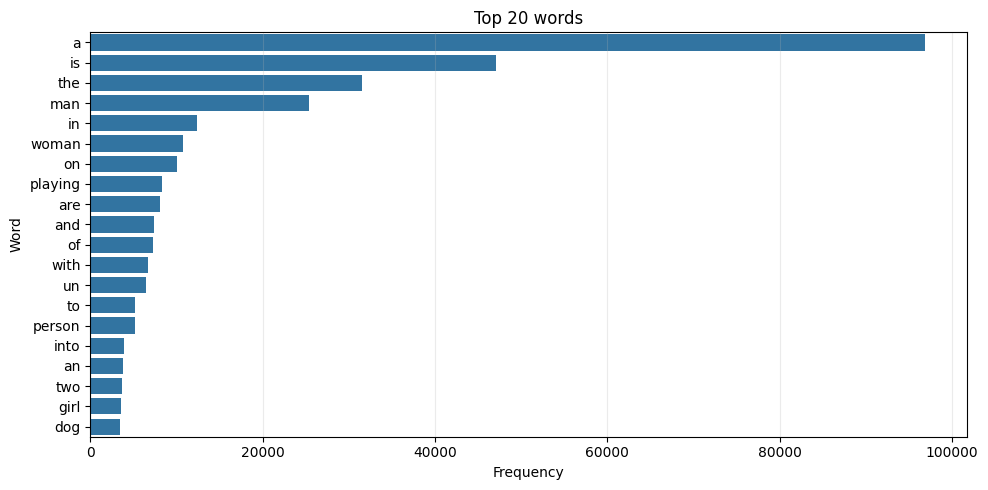

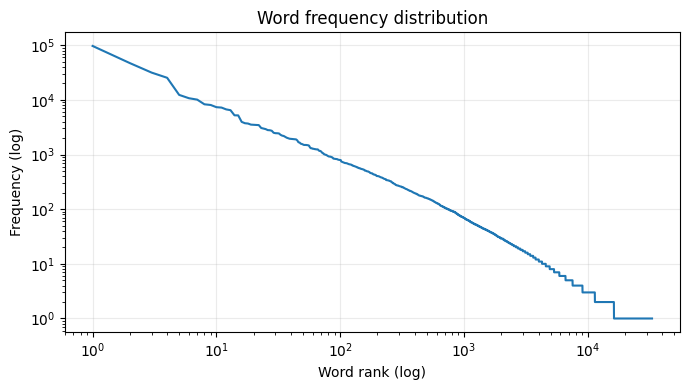

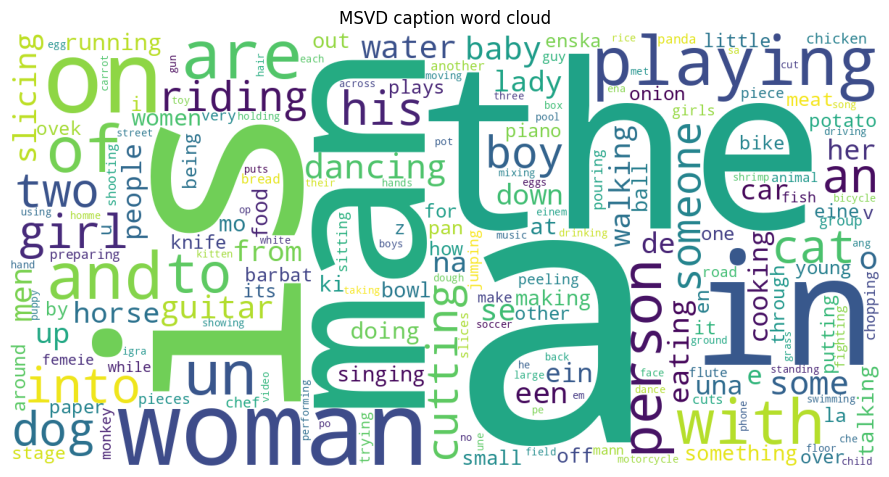

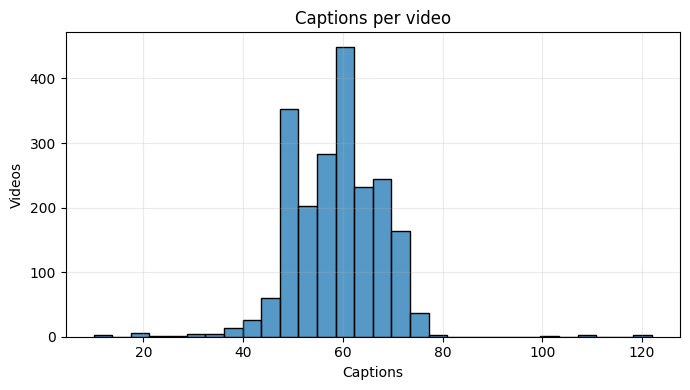

In [ ]:
import re
from wordcloud import WordCloud
FIG = OUT / "results/figures"
def savefig(name):
    plt.tight_layout(); plt.savefig(FIG / name, dpi=220, bbox_inches="tight"); plt.show()
captions["word_count"] = captions.caption.str.findall(r"[A-Za-z']+").str.len()
words = [w.lower() for text in captions.caption for w in re.findall(r"[A-Za-z']+", text)]
freq = Counter(words)
fig, ax = plt.subplots(figsize=(8,4)); sns.histplot(captions.word_count, bins=30, ax=ax); ax.set(title="Caption length distribution", xlabel="Words per caption", ylabel="Caption records"); ax.grid(alpha=.25); savefig("caption_length_histogram.png")
fig, ax = plt.subplots(figsize=(7,3)); sns.boxplot(x=captions.word_count, ax=ax); ax.set(title="Caption word-count boxplot", xlabel="Words per caption", ylabel="Count"); ax.grid(alpha=.25); savefig("caption_wordcount_boxplot.png")
top = pd.DataFrame(freq.most_common(20), columns=["word","count"]); fig, ax = plt.subplots(figsize=(10,5)); sns.barplot(data=top, x="count", y="word", ax=ax); ax.set(title="Top 20 words", xlabel="Frequency", ylabel="Word"); ax.grid(axis="x", alpha=.25); savefig("top_words.png")
ranked = sorted(freq.values(), reverse=True); fig, ax = plt.subplots(figsize=(7,4)); ax.loglog(range(1,len(ranked)+1), ranked); ax.set(title="Word frequency distribution", xlabel="Word rank (log)", ylabel="Frequency (log)"); ax.grid(alpha=.25); savefig("word_frequency_distribution.png")
fig, ax = plt.subplots(figsize=(9,5)); ax.imshow(WordCloud(width=1200,height=600,background_color="white").generate_from_frequencies(freq)); ax.axis("off"); ax.set_title("MSVD caption word cloud"); savefig("wordcloud.png")
counts = captions.groupby("video_id").size(); fig, ax = plt.subplots(figsize=(7,4)); sns.histplot(counts, bins=30, ax=ax); ax.set(title="Captions per video", xlabel="Captions", ylabel="Videos"); ax.grid(alpha=.25); savefig("captions_per_video.png")


# 4. Dataset Splitting


In [ ]:
def split_by_video_id(frame, train_ratio=.8, val_ratio=.1, test_ratio=.1, seed=42):
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1): raise ValueError("Split ratios must sum to 1.")
    ids = np.array(sorted(frame.video_id.unique()))
    train_ids, holdout = train_test_split(ids, test_size=val_ratio+test_ratio, random_state=seed, shuffle=True)
    val_ids, test_ids = train_test_split(holdout, test_size=test_ratio/(val_ratio+test_ratio), random_state=seed, shuffle=True)
    sets = {"train":set(train_ids), "validation":set(val_ids), "test":set(test_ids)}
    assert not (sets["train"] & sets["validation"] or sets["train"] & sets["test"] or sets["validation"] & sets["test"])
    return sets

splits = split_by_video_id(captions, CFG.TRAIN_RATIO, CFG.VAL_RATIO, CFG.TEST_RATIO, CFG.SEED)
split_names = {"train":"train_video_ids.csv", "validation":"val_video_ids.csv", "test":"test_video_ids.csv"}
rows=[]
for name, ids in splits.items():
    pd.DataFrame({"video_id":sorted(ids)}).to_csv(OUT / split_names[name], index=False)
    rows.append({"Split":name, "Unique Videos":len(ids), "Caption Records":captions.video_id.isin(ids).sum()})
split_table=pd.DataFrame(rows); display(split_table)
split_metadata={k:sorted(v) for k,v in splits.items()}
with open(OUT / "configs/split_metadata.json", "w") as f: json.dump(split_metadata, f, indent=2)
print("Verified: train ∩ validation = train ∩ test = validation ∩ test = ∅")


,Split,Unique Videos,Caption Records
0,train,1670,98005
1,validation,209,12315
2,test,209,12284


Verified: train ∩ validation = train ∩ test = validation ∩ test = ∅


# 5. Video Preprocessing


Inspecting videos:   0%|          | 0/25 [00:00<?, ?it/s]

,video_id,path,readable,fps,frame_count,width,height,duration_s,error
0,EdrZtaBUXIo_25_29,/content/msvd/YouTubeClips/EdrZtaBUXIo_25_29.avi,True,29.970030,120,720,480,4.004000,
1,p69d3UBdpR8_98_109,/content/msvd/YouTubeClips/p69d3UBdpR8_98_109.avi,True,30.000000,331,480,360,11.033333,
2,6t0BpjwYKco_217_229,/content/msvd/YouTubeClips/6t0BpjwYKco_217_229...,True,29.916667,360,320,240,12.033426,
3,mmSQTI6gMNQ_120_128,/content/msvd/YouTubeClips/mmSQTI6gMNQ_120_128...,True,29.970030,240,320,240,8.008000,
4,IpHJffM3G1c_464_470,/content/msvd/YouTubeClips/IpHJffM3G1c_464_470...,True,29.968000,180,1280,720,6.006407,


Unreadable videos logged: 0


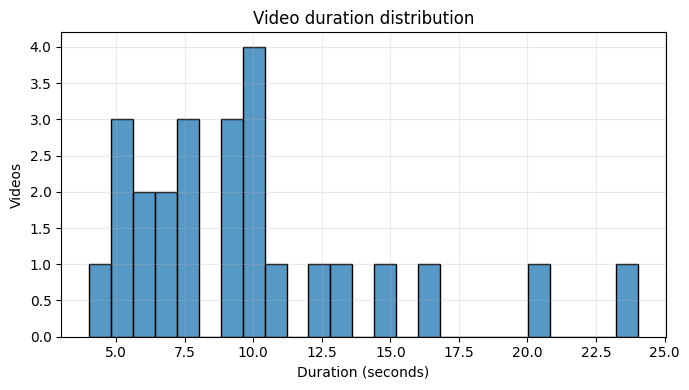

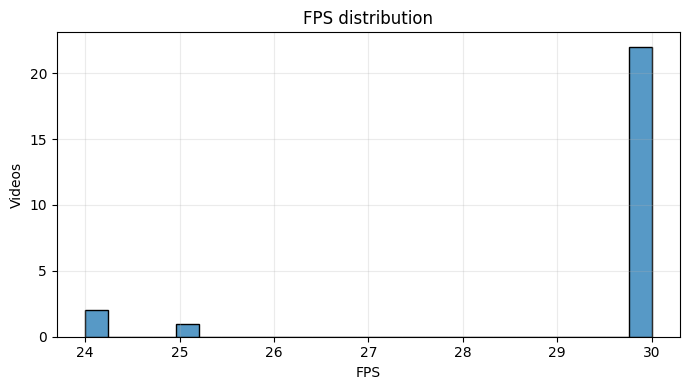

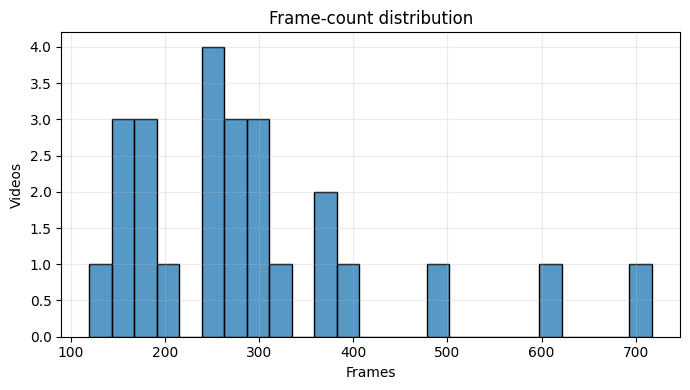

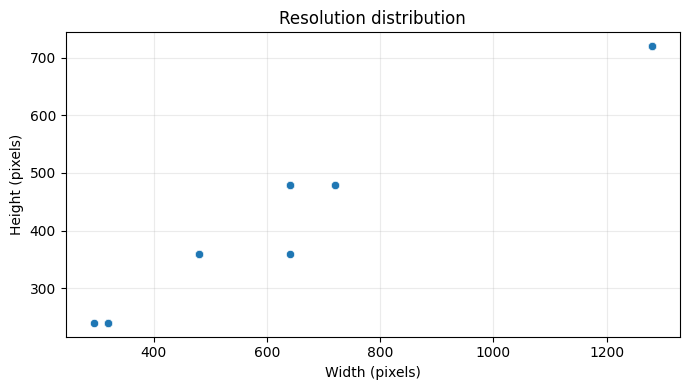

In [ ]:
def inspect_video(video_path):
    cap=cv2.VideoCapture(str(video_path))
    try:
        if not cap.isOpened(): raise RuntimeError("OpenCV could not decode video")
        fps=float(cap.get(cv2.CAP_PROP_FPS)); n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        if fps <= 0 or n <= 0: raise RuntimeError(f"invalid fps/frame_count ({fps}, {n})")
        return {"readable":True,"fps":fps,"frame_count":n,"width":w,"height":h,"duration_s":n/fps,"error":""}
    except Exception as exc: return {"readable":False,"fps":np.nan,"frame_count":np.nan,"width":np.nan,"height":np.nan,"duration_s":np.nan,"error":str(exc)}
    finally: cap.release()

def build_video_metadata(paths, run_all=False):
    iterable=list(paths.items()) if run_all else list(paths.items())[:min(25,len(paths))]
    records=[]
    for vid, path in tqdm(iterable, desc="Inspecting videos"):
        records.append({"video_id":vid,"path":str(path), **inspect_video(path)})
    meta=pd.DataFrame(records); meta.to_csv(OUT/"results/video_metadata.csv", index=False); return meta

video_metadata=build_video_metadata(video_paths, CFG.RUN_FULL_METADATA)
display(video_metadata.head()); print("Unreadable videos logged:", (~video_metadata.readable).sum())
if not video_metadata.empty:
    for col, title, xlab in [("duration_s","Video duration distribution","Duration (seconds)"),("fps","FPS distribution","FPS"),("frame_count","Frame-count distribution","Frames")]:
        fig,ax=plt.subplots(figsize=(7,4)); sns.histplot(video_metadata.loc[video_metadata.readable,col].dropna(), bins=25, ax=ax); ax.set(title=title,xlabel=xlab,ylabel="Videos"); ax.grid(alpha=.25); savefig(f"{col}_distribution.png")
    fig,ax=plt.subplots(figsize=(7,4)); sns.scatterplot(data=video_metadata[video_metadata.readable],x="width",y="height",ax=ax); ax.set(title="Resolution distribution",xlabel="Width (pixels)",ylabel="Height (pixels)"); ax.grid(alpha=.25); savefig("resolution_distribution.png")


# 6. Candidate Frame Extraction


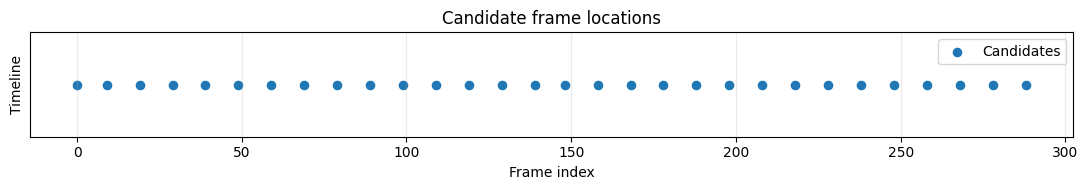

GlW6n43pUQA_0_12 30 candidate frames


In [ ]:
def extract_candidate_frames(video_path, num_frames):
    """Decode only temporally-spaced candidates; returns RGB PIL frames, indices, timestamps."""
    cap=cv2.VideoCapture(str(video_path))
    if not cap.isOpened(): raise RuntimeError(f"Cannot open {video_path}")
    try:
        total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); fps=float(cap.get(cv2.CAP_PROP_FPS))
        indices=np.unique(np.linspace(0, max(total-1,0), min(num_frames,total), dtype=int))
        frames=[]; actual=[]
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx)); ok, bgr=cap.read()
            if ok: frames.append(Image.fromarray(cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB))); actual.append(int(idx))
        return frames, actual, [i/fps for i in actual]
    finally: cap.release()

def cached_candidates(video_id):
    cache=OUT / "cache" / f"{video_id}_candidates.npz"
    # Cache compact thumbnails, not thousands of source images.
    if cache.exists():
        z=np.load(cache, allow_pickle=True); return [Image.fromarray(x) for x in z["frames"]], z["indices"].tolist(), z["times"].tolist()
    frames,indices,times=extract_candidate_frames(video_paths[video_id], CFG.NUM_CANDIDATE_FRAMES)
    thumbs=np.stack([np.asarray(f.resize((CFG.IMAGE_SIZE,CFG.IMAGE_SIZE))) for f in frames])
    np.savez_compressed(cache,frames=thumbs,indices=np.array(indices),times=np.array(times)); return frames,indices,times

def plot_timeline(indices, selected=None, title="Candidate frame locations"):
    fig,ax=plt.subplots(figsize=(11,2)); ax.scatter(indices,np.ones(len(indices)),label="Candidates",s=35)
    if selected is not None: ax.scatter(selected,np.ones(len(selected))*1.04,label="Selected",s=60,marker="*")
    ax.set(title=title,xlabel="Frame index",ylabel="Timeline"); ax.set_yticks([]); ax.grid(axis="x",alpha=.25); ax.legend(); savefig(title.lower().replace(" ","_")+".png")

sample_video_id=next(iter(splits["validation"] & set(video_paths)), None)
if sample_video_id:
    sample_frames,sample_indices,sample_times=cached_candidates(sample_video_id); plot_timeline(sample_indices, title="Candidate frame locations")
    print(sample_video_id, len(sample_frames), "candidate frames")


# 7. Baseline Frame Sampling


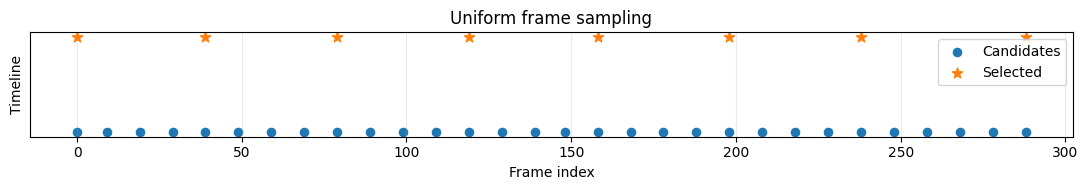

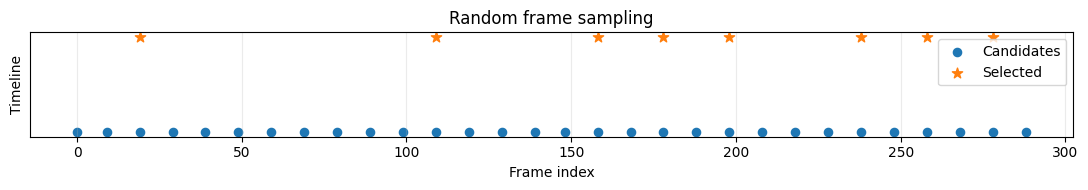

In [ ]:
def uniform_selection(indices, k):
    return np.asarray(indices)[np.unique(np.linspace(0,len(indices)-1,min(k,len(indices)),dtype=int))].tolist()
def random_selection(indices, k, seed=42):
    rng=np.random.default_rng(seed); return sorted(rng.choice(np.asarray(indices),size=min(k,len(indices)),replace=False).tolist())
if sample_video_id:
    plot_timeline(sample_indices,uniform_selection(sample_indices,CFG.NUM_SELECTED_FRAMES),"Uniform frame sampling")
    plot_timeline(sample_indices,random_selection(sample_indices,CFG.NUM_SELECTED_FRAMES,CFG.SEED),"Random frame sampling")


# 8. Motion-Based Frame Selection


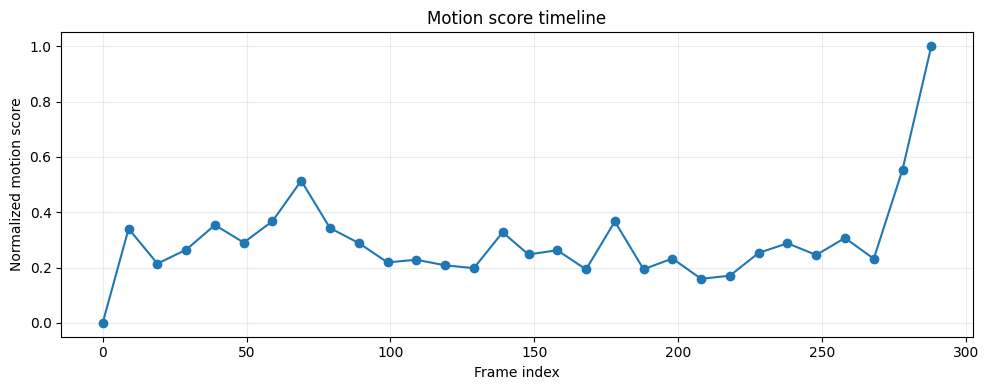

In [ ]:
def minmax(scores):
    scores=np.asarray(scores,dtype=float)
    return np.zeros_like(scores) if len(scores)==0 or np.ptp(scores)<1e-12 else (scores-scores.min())/np.ptp(scores)

def motion_scores(frames):
    """Downsampled Farnebäck flow gives a T4-friendly candidate-level motion proxy."""
    if len(frames)==0: return np.array([])
    gray=[cv2.resize(cv2.cvtColor(np.asarray(f),cv2.COLOR_RGB2GRAY),(160,120)) for f in frames]
    score=[0.0]
    for prev,cur in zip(gray[:-1],gray[1:]):
        flow=cv2.calcOpticalFlowFarneback(prev,cur,None,.5,3,15,3,5,1.2,0)
        score.append(float(np.linalg.norm(flow,axis=2).mean()))
    return minmax(score)

if sample_video_id:
    sample_motion=motion_scores(sample_frames)
    pd.DataFrame({"video_id":sample_video_id,"frame_index":sample_indices,"timestamp":sample_times,"motion_score":sample_motion}).to_csv(OUT/"results/frame_scores/motion_scores.csv",index=False)
    fig,ax=plt.subplots(figsize=(10,4)); ax.plot(sample_indices,sample_motion,marker="o"); ax.set(title="Motion score timeline",xlabel="Frame index",ylabel="Normalized motion score"); ax.grid(alpha=.25); savefig("motion_score_timeline.png")


# 9. Semantic Frame Selection


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

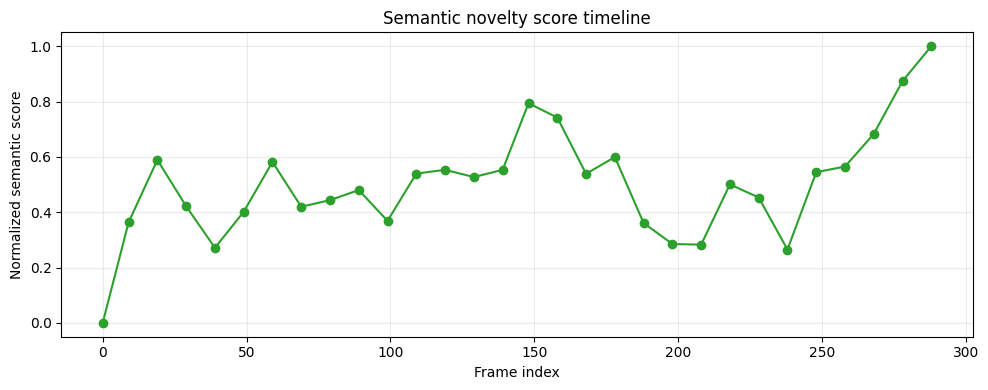

In [ ]:
from transformers import AutoImageProcessor, AutoModel
semantic_processor=None; semantic_model=None
def load_semantic_encoder():
    global semantic_processor, semantic_model
    if semantic_model is None:
        name="facebook/dinov2-small"  # lightweight, caption-independent frozen vision encoder
        semantic_processor=AutoImageProcessor.from_pretrained(name)
        semantic_model=AutoModel.from_pretrained(name).to(device).eval()
    return semantic_processor,semantic_model

@torch.inference_mode()
def semantic_scores(frames, batch_size=16):
    if not frames: return np.array([]), np.empty((0,0))
    processor,model=load_semantic_encoder(); vectors=[]
    for start in range(0,len(frames),batch_size):
        inputs=processor(images=frames[start:start+batch_size],return_tensors="pt").to(device)
        emb=model(**inputs).last_hidden_state[:,0].float(); vectors.append(torch.nn.functional.normalize(emb,dim=-1).cpu())
    emb=torch.cat(vectors).numpy(); novelty=np.zeros(len(emb))
    if len(emb)>1: novelty[1:]=1-(emb[1:]*emb[:-1]).sum(axis=1)
    return minmax(novelty),emb

if sample_video_id:
    sample_semantic,sample_embeddings=semantic_scores(sample_frames)
    np.save(OUT/f"cache/{sample_video_id}_embeddings.npy",sample_embeddings)
    fig,ax=plt.subplots(figsize=(10,4)); ax.plot(sample_indices,sample_semantic,marker="o",color="tab:green"); ax.set(title="Semantic novelty score timeline",xlabel="Frame index",ylabel="Normalized semantic score"); ax.grid(alpha=.25); savefig("semantic_score_timeline.png")


# 10. Adaptive Semantic-Motion Keyframe Selection


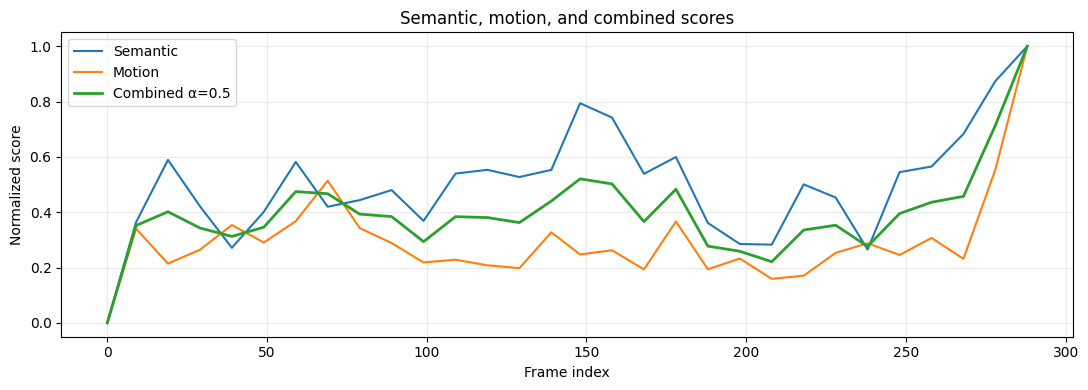

In [ ]:
def fused_scores(semantic, motion, alpha): return alpha*minmax(semantic)+(1-alpha)*minmax(motion)
if sample_video_id:
    sample_combined=fused_scores(sample_semantic,sample_motion,CFG.ALPHA)
    fig,ax=plt.subplots(figsize=(11,4)); ax.plot(sample_indices,sample_semantic,label="Semantic"); ax.plot(sample_indices,sample_motion,label="Motion"); ax.plot(sample_indices,sample_combined,label=f"Combined α={CFG.ALPHA}",linewidth=2); ax.set(title="Semantic, motion, and combined scores",xlabel="Frame index",ylabel="Normalized score"); ax.grid(alpha=.25); ax.legend(); savefig("combined_score_timeline.png")


# 11. Temporal Diversity Filtering


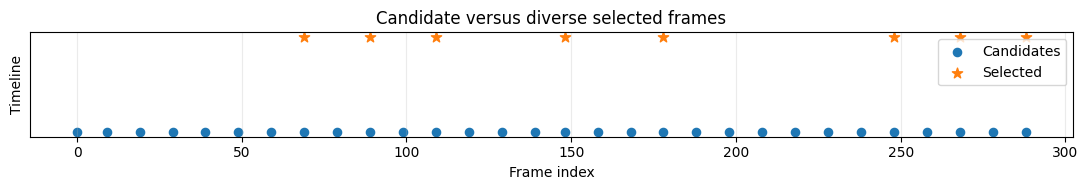

In [ ]:
def select_diverse_keyframes(indices, scores, timestamps, k, min_temporal_distance):
    """Greedy temporal NMS with deterministic best-available backfill."""
    order=np.argsort(scores)[::-1]; chosen=[]
    for pos in order:
        if all(abs(timestamps[pos]-timestamps[q]) >= min_temporal_distance for q in chosen):
            chosen.append(int(pos))
        if len(chosen)==k: break
    for pos in order:  # required backfill for short clips / dense candidates
        if len(chosen)==k: break
        if int(pos) not in chosen: chosen.append(int(pos))
    chosen=sorted(chosen)
    return [indices[i] for i in chosen], [float(scores[i]) for i in chosen], [float(timestamps[i]) for i in chosen]

def select_frames(video_id, method, k=None, alpha=None):
    k=k or CFG.NUM_SELECTED_FRAMES; alpha=CFG.ALPHA if alpha is None else alpha
    frames,indices,times=cached_candidates(video_id)
    if method=="uniform": selected=uniform_selection(indices,k); score=np.zeros(len(indices))
    elif method=="random": selected=random_selection(indices,k,CFG.SEED); score=np.zeros(len(indices))
    else:
        motion=motion_scores(frames); semantic,_=semantic_scores(frames)
        score={"motion":motion,"semantic":semantic,"semantic_motion":fused_scores(semantic,motion,alpha),"semantic_motion_diverse":fused_scores(semantic,motion,alpha)}[method]
        if method=="semantic_motion_diverse": selected,_,_=select_diverse_keyframes(indices,score,times,k,CFG.MIN_TEMPORAL_DISTANCE)
        else: selected=sorted(np.asarray(indices)[np.argsort(score)[::-1][:min(k,len(indices))]].tolist())
    take=[indices.index(i) for i in selected]
    return [frames[i] for i in take], selected, [times[i] for i in take], score

if sample_video_id:
    _,chosen,_,_=select_frames(sample_video_id,"semantic_motion_diverse")
    plot_timeline(sample_indices,chosen,"Candidate versus diverse selected frames")


# 12. BLIP-2 Model Setup


In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

def make_contact_sheet(frames, image_size=224):
    """A deterministic visual storyboard lets one-image BLIP-2 consume all K selected frames."""
    if not frames: raise ValueError("No decoded frames")
    cols=math.ceil(math.sqrt(len(frames))); rows=math.ceil(len(frames)/cols)
    sheet=Image.new("RGB",(cols*image_size,rows*image_size),(0,0,0))
    for i,frame in enumerate(frames): sheet.paste(frame.convert("RGB").resize((image_size,image_size)),((i%cols)*image_size,(i//cols)*image_size))
    return sheet

class BLIP2VideoCaptioner:
    def __init__(self, config): self.cfg=config; self.processor=None; self.model=None
    def load_model(self):
        if self.model is not None: return self
        if device=="cuda": print(f"Loading {self.cfg.MODEL_NAME} in fp16; free GPU memory: {(torch.cuda.mem_get_info()[0]/2**30):.2f} GB")
        kwargs={"torch_dtype":torch.float16 if device=="cuda" else torch.float32}
        if self.cfg.USE_4BIT: kwargs.update(load_in_4bit=True, device_map="auto")
        self.processor=Blip2Processor.from_pretrained(self.cfg.MODEL_NAME)
        self.model=Blip2ForConditionalGeneration.from_pretrained(self.cfg.MODEL_NAME, **kwargs)
        if not self.cfg.USE_4BIT: self.model.to(device)
        self.model.eval(); return self
    def prepare_frames(self, frames): return make_contact_sheet(frames,self.cfg.IMAGE_SIZE)
    @torch.inference_mode()
    def generate_caption(self, frames, prompt="A short video of"):
        sheet=self.prepare_frames(frames); inputs=self.processor(images=sheet,text=prompt,return_tensors="pt").to(device, torch.float16 if device=="cuda" else torch.float32)
        tokens=self.model.generate(**inputs,max_new_tokens=self.cfg.MAX_CAPTION_LENGTH,num_beams=3)
        return self.processor.batch_decode(tokens,skip_special_tokens=True)[0].strip()
    def generate_batch(self, frame_batches): return [self.generate_caption(x) for x in frame_batches]
    def save_checkpoint(self, path, extra=None):
        Path(path).mkdir(parents=True,exist_ok=True); self.model.save_pretrained(path); self.processor.save_pretrained(path); json.dump(extra or {},open(Path(path)/"metadata.json","w"),indent=2)
    def load_checkpoint(self,path):
        self.processor=Blip2Processor.from_pretrained(path); self.model=Blip2ForConditionalGeneration.from_pretrained(path,torch_dtype=torch.float16 if device=="cuda" else torch.float32).to(device).eval(); return self

captioner=BLIP2VideoCaptioner(CFG)
print("Configured model:",CFG.MODEL_NAME,"— download only when the next cell is run.")


Configured model: Salesforce/blip2-opt-2.7b — download only when the next cell is run.


# 13. Zero-Shot Baseline


In [ ]:
def references_for(video_id): return captions.loc[captions.video_id.eq(video_id),"caption"].tolist()
def zero_shot_smoke_test(video_ids):
    captioner.load_model(); records=[]
    for vid in tqdm(list(video_ids)[:CFG.SMOKE_TEST_VIDEOS],desc="Zero-shot smoke test"):
        frames,indices,_,_=select_frames(vid,"uniform"); pred=captioner.generate_caption(frames)
        records.append({"video_id":vid,"sampling_method":"uniform","selected_frame_indices":json.dumps(indices),"caption":pred,"references":references_for(vid)})
    result=pd.DataFrame(records); display(result[["video_id","selected_frame_indices","caption","references"]]); return result

# Run only after paths are verified; this downloads BLIP-2 once.
# smoke_predictions = zero_shot_smoke_test(sorted(splits["validation"] & set(video_paths)))


# 14. BLIP-2 Fine-Tuning


In [ ]:
from torch.utils.data import Dataset, DataLoader
from transformers import get_linear_schedule_with_warmup

class VideoCaptionDataset(Dataset):
    def __init__(self, ids, method): self.ids=[x for x in ids if x in video_paths]; self.method=method
    def __len__(self): return len(self.ids)
    def __getitem__(self,i):
        vid=self.ids[i]; frames,_,_,_=select_frames(vid,self.method)
        # A random ground-truth caption per video each epoch avoids duplicate-caption row sampling.
        caption=random.choice(references_for(vid)); return vid, make_contact_sheet(frames,CFG.IMAGE_SIZE), caption

def collate_caption_batch(batch):
    vids,images,texts=zip(*batch); inputs=captioner.processor(images=list(images),text=list(texts),padding=True,return_tensors="pt")
    labels=inputs.input_ids.clone(); labels[labels==captioner.processor.tokenizer.pad_token_id]=-100; inputs["labels"]=labels
    return vids, {k:v.to(device) for k,v in inputs.items()}

def configure_lora(model):
    if not CFG.USE_LORA: return model
    from peft import LoraConfig, get_peft_model
    for p in model.parameters(): p.requires_grad=False
    config=LoraConfig(r=8,lora_alpha=16,lora_dropout=.05,target_modules=["q_proj","v_proj"],bias="none")
    model=get_peft_model(model,config); model.print_trainable_parameters(); return model

def gpu_memory_gb(): return torch.cuda.max_memory_allocated()/2**30 if torch.cuda.is_available() else 0.0
def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train(); running=0.; optimizer.zero_grad(set_to_none=True); start=time.perf_counter()
    for step,(_,batch) in enumerate(tqdm(loader,leave=False)):
        with torch.cuda.amp.autocast(enabled=device=="cuda"):
            loss=model(**batch).loss/CFG.GRADIENT_ACCUMULATION_STEPS
        scaler.scale(loss).backward()
        if (step+1)%CFG.GRADIENT_ACCUMULATION_STEPS==0 or step+1==len(loader):
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True); scheduler.step()
        running += loss.item()*CFG.GRADIENT_ACCUMULATION_STEPS
    return running/max(1,len(loader)),time.perf_counter()-start

@torch.no_grad()
def validate(model,loader):
    model.eval(); losses=[]
    for _,batch in loader:
        with torch.cuda.amp.autocast(enabled=device=="cuda"): losses.append(model(**batch).loss.item())
    return float(np.mean(losses)) if losses else float("nan")

def save_checkpoint(model, directory, epoch, history):
    directory=Path(directory); directory.mkdir(parents=True,exist_ok=True); model.save_pretrained(directory/f"epoch_{epoch}"); json.dump(history,open(directory/"history.json","w"),indent=2)


# 15. Proposed Method Fine-Tuning


In [ ]:
def run_finetuning(method, checkpoint_dir):
    """Same architecture/hyperparameters for uniform and adaptive control conditions."""
    captioner.load_model(); model=configure_lora(captioner.model)
    train_ids=sorted(splits["train"] & set(video_paths)); val_ids=sorted(splits["validation"] & set(video_paths))
    if CFG.MAX_TRAIN_VIDEOS: train_ids=train_ids[:CFG.MAX_TRAIN_VIDEOS]; val_ids=val_ids[:max(1,CFG.MAX_TRAIN_VIDEOS//8)]
    train_loader=DataLoader(VideoCaptionDataset(train_ids,method),batch_size=CFG.BATCH_SIZE,shuffle=True,num_workers=CFG.NUM_WORKERS,collate_fn=collate_caption_batch)
    val_loader=DataLoader(VideoCaptionDataset(val_ids,method),batch_size=CFG.BATCH_SIZE,num_workers=CFG.NUM_WORKERS,collate_fn=collate_caption_batch)
    opt=torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),lr=CFG.LEARNING_RATE)
    steps=math.ceil(len(train_loader)/CFG.GRADIENT_ACCUMULATION_STEPS)*CFG.NUM_EPOCHS; sched=get_linear_schedule_with_warmup(opt,max(1,int(.1*steps)),max(1,steps)); scaler=torch.cuda.amp.GradScaler(enabled=device=="cuda")
    hist=[]; best=float("inf"); patience=0
    for epoch in range(1,CFG.NUM_EPOCHS+1):
        tr,seconds=train_one_epoch(model,train_loader,opt,sched,scaler); va=validate(model,val_loader); row={"epoch":epoch,"train_loss":tr,"val_loss":va,"lr":sched.get_last_lr()[0],"epoch_time_s":seconds}; hist.append(row); print(row)
        if va<best: best=va; patience=0; save_checkpoint(model,checkpoint_dir,epoch,hist)
        else: patience+=1
        if patience>=2: print("Early stopping"); break
    pd.DataFrame(hist).to_csv(OUT/f"results/logs/{method}_training.csv",index=False)
    fig,ax=plt.subplots(figsize=(7,4)); pd.DataFrame(hist).plot(x="epoch",y=["train_loss","val_loss"],marker="o",ax=ax); ax.set(title=f"{method}: training and validation loss",xlabel="Epoch",ylabel="Loss"); ax.grid(alpha=.25); savefig(f"{method}_training_curve.png")
    return hist

# Controlled experiment: enable CFG.RUN_FINETUNING after the zero-shot smoke test.
if CFG.RUN_FINETUNING:
    uniform_history=run_finetuning("uniform",OUT/"checkpoints/uniform_baseline")
    proposed_history=run_finetuning("semantic_motion_diverse",OUT/"checkpoints/proposed")


# 16. Caption Generation


In [ ]:
def generate_for_ids(video_ids, method, alpha=None, checkpoint=None):
    if checkpoint: captioner.load_checkpoint(checkpoint)
    else: captioner.load_model()
    output=[]
    for vid in tqdm(video_ids,desc=f"Generate {method}"):
        begin=time.perf_counter();
        try:
            frames,indices,_,_=select_frames(vid,method,alpha=alpha); pred=captioner.generate_caption(frames); elapsed=time.perf_counter()-begin
            output.append({"video_id":vid,"sampling_method":method,"selected_frame_indices":json.dumps(indices),"caption":pred,"inference_time_s":elapsed,"gpu_memory_gb":gpu_memory_gb()})
        except Exception as exc: output.append({"video_id":vid,"sampling_method":method,"error":str(exc)})
    current=pd.DataFrame(output); current.to_csv(OUT/f"results/generated_captions/{method}_captions.csv",index=False)
    # Also maintain the requested experiment-wide, tidy caption ledger without duplicating reruns.
    ledger_path=OUT/"results/generated_captions.csv"
    if ledger_path.exists():
        ledger=pd.read_csv(ledger_path); ledger=ledger[~ledger.set_index(["video_id","sampling_method"]).index.isin(current.set_index(["video_id","sampling_method"]).index)]
        ledger=pd.concat([ledger,current],ignore_index=True)
    else: ledger=current
    ledger.to_csv(ledger_path,index=False); return current

# Example: generated = generate_for_ids(sorted(splits["test"] & set(video_paths)), "semantic_motion_diverse")


# 17. Automatic Evaluation


In [ ]:
import nltk
for resource in ["wordnet","omw-1.4"]:
    try: nltk.data.find("corpora/"+resource)
    except LookupError: nltk.download(resource,quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

def evaluate_captions(predictions, references):
    """references is {video_id: [reference caption,...]}; no references enter frame selection/training."""
    pairs=[(str(r.caption),references.get(r.video_id,[])) for r in predictions.itertuples() if r.video_id in references and references[r.video_id]]
    if not pairs: return {k:np.nan for k in ["BLEU-1","BLEU-2","BLEU-3","BLEU-4","METEOR","ROUGE-L","CIDEr"]}
    hyp=[p.split() for p,_ in pairs]; refs=[[x.split() for x in rs] for _,rs in pairs]; smooth=SmoothingFunction().method1
    result={f"BLEU-{n}":corpus_bleu(refs,hyp,weights=tuple([1/n]*n),smoothing_function=smooth) for n in range(1,5)}
    result["METEOR"]=np.mean([meteor_score([x.split() for x in rs],p.split()) for p,rs in pairs])
    rouge=rouge_scorer.RougeScorer(["rougeL"],use_stemmer=True); result["ROUGE-L"]=np.mean([max(rouge.score(x,p)["rougeL"].fmeasure for x in rs) for p,rs in pairs])
    result["CIDEr"]=np.nan
    try:
        from pycocoevalcap.cider.cider import Cider
        gts={str(i):rs for i,(_,rs) in enumerate(pairs)}; res={str(i):[p] for i,(p,_) in enumerate(pairs)}; result["CIDEr"]=Cider().compute_score(gts,res)[0]
    except Exception as exc: print("CIDEr unavailable (install pycocoevalcap if desired):",type(exc).__name__)
    return result

test_references={vid:references_for(vid) for vid in splits["test"]}


# 18. Ablation Study


In [ ]:
METHODS=["uniform","random","motion","semantic","semantic_motion","semantic_motion_diverse"]
def run_ablation(ids, methods=METHODS):
    rows=[]
    for method in methods:
        torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None
        preds=generate_for_ids(ids,method); metric=evaluate_captions(preds,test_references)
        rows.append({"Method":method,"Frames":CFG.NUM_SELECTED_FRAMES,**metric,"Inference Time":preds.inference_time_s.mean(),"GPU Memory":gpu_memory_gb()})
    table=pd.DataFrame(rows); table.to_csv(OUT/"results/metrics/ablation_metrics.csv",index=False); table.to_csv(OUT/"results/metrics.csv",index=False); return table
if CFG.RUN_TEST_ABLATIONS:
    ablation=run_ablation(sorted(splits["test"] & set(video_paths))); display(ablation)
    fig,ax=plt.subplots(figsize=(10,4)); sns.barplot(data=ablation,x="Method",y="BLEU-4",ax=ax); ax.tick_params(axis="x",rotation=30); ax.set(title="Ablation comparison",xlabel="Method",ylabel="BLEU-4"); ax.grid(axis="y",alpha=.25); savefig("ablation_comparison.png")


# 19. Frame Budget Study


In [ ]:
def frame_budget_study(ids, budgets=(4,8,12,16)):
    records=[]
    original=CFG.NUM_SELECTED_FRAMES
    try:
        for k in budgets:
            CFG.NUM_SELECTED_FRAMES=k
            for method in ["uniform","semantic_motion_diverse"]:
                if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
                pred=generate_for_ids(ids,method); metrics=evaluate_captions(pred,test_references)
                records.append({"Method":method,"Frames":k,**metrics,"Inference Time":pred.inference_time_s.mean(),"GPU Memory":gpu_memory_gb()})
    finally: CFG.NUM_SELECTED_FRAMES=original
    df=pd.DataFrame(records); df.to_csv(OUT/"results/metrics/frame_budget.csv",index=False); return df
if CFG.RUN_FRAME_BUDGET_STUDY:
    budget_results=frame_budget_study(sorted(splits["test"] & set(video_paths)))
    for y,title in [("CIDEr","Frame count versus CIDEr"),("Inference Time","Frame count versus inference time"),("GPU Memory","Frame count versus GPU memory")]:
        fig,ax=plt.subplots(figsize=(7,4)); sns.lineplot(data=budget_results,x="Frames",y=y,hue="Method",marker="o",ax=ax); ax.set(title=title,xlabel="Selected frames",ylabel=y); ax.grid(alpha=.25); savefig(title.lower().replace(" ","_")+".png")


# 20. Efficiency Analysis


In [ ]:
def efficiency_row(video_id, method):
    start=time.perf_counter(); frames,indices,times=cached_candidates(video_id); extraction=time.perf_counter()-start
    start=time.perf_counter(); motion=motion_scores(frames); motion_time=time.perf_counter()-start
    start=time.perf_counter(); semantic,_=semantic_scores(frames); semantic_time=time.perf_counter()-start
    selected,_,_,_=select_frames(video_id,method); start=time.perf_counter(); _=captioner.generate_caption(selected); inference=time.perf_counter()-start
    return {"Method":method,"Candidate Frames":len(frames),"Frames":len(selected),"Frame Reduction":1-len(selected)/len(frames),"Frame Extraction Time":extraction,"Motion Scoring Time":motion_time,"Semantic Embedding Time":semantic_time,"BLIP-2 Inference Time":inference,"Total Inference Time":extraction+motion_time+semantic_time+inference,"GPU Memory":gpu_memory_gb()}

def plot_efficiency(efficiency):
    fig,ax=plt.subplots(figsize=(7,4)); sns.barplot(data=efficiency,x="Method",y="Frame Reduction",ax=ax); ax.set(title="Frame reduction comparison",xlabel="Method",ylabel="Frame reduction"); ax.grid(axis="y",alpha=.25); savefig("frame_reduction_comparison.png")
    return efficiency

# After `captioner.load_model()`: efficiency = plot_efficiency(pd.DataFrame([efficiency_row(sample_video_id,m) for m in ["uniform","semantic_motion_diverse"]])); display(efficiency)


# 21. Qualitative Analysis


In [ ]:
def qualitative_analysis(test_ids, n=5):
    ids=np.random.default_rng(CFG.SEED).choice(sorted(test_ids),size=min(n,len(test_ids)),replace=False)
    captioner.load_model(); records=[]
    for vid in ids:
        uni,ui,_,_=select_frames(vid,"uniform"); prop,pi,_,_=select_frames(vid,"semantic_motion_diverse")
        fig,axes=plt.subplots(2,max(len(uni),len(prop)),figsize=(16,4))
        for row,fs,title in zip(axes,[uni,prop],["Uniform","Adaptive semantic-motion"]):
            for ax,fr in zip(row,fs): ax.imshow(fr); ax.axis("off")
            row[0].set_ylabel(title,fontsize=11)
        fig.suptitle(f"{vid} | References: {' | '.join(references_for(vid)[:2])}",fontsize=10); plt.tight_layout(); plt.savefig(OUT/f"results/qualitative/{vid}.png",dpi=180); plt.show()
        records.append({"video_id":vid,"references":references_for(vid),"uniform_caption":captioner.generate_caption(uni),"proposed_caption":captioner.generate_caption(prop),"uniform_indices":ui,"proposed_indices":pi})
    return pd.DataFrame(records)
# qualitative = qualitative_analysis(splits["test"] & set(video_paths))


# 22. Results Visualization


In [ ]:
def plot_alpha_sensitivity(validation_ids, alphas=(0,.25,.5,.75,1.0)):
    rows=[]
    for alpha in alphas:
        preds=generate_for_ids(validation_ids,"semantic_motion_diverse",alpha=alpha)
        refs={v:references_for(v) for v in validation_ids}; rows.append({"alpha":alpha,**evaluate_captions(preds,refs)})
    df=pd.DataFrame(rows); df.to_csv(OUT/"results/metrics/alpha_validation.csv",index=False)
    for metric in ["CIDEr","BLEU-4"]:
        fig,ax=plt.subplots(figsize=(6,4)); sns.lineplot(data=df,x="alpha",y=metric,marker="o",ax=ax); ax.set(title=f"Alpha sensitivity ({metric}, validation only)",xlabel="Semantic weight α",ylabel=metric); ax.grid(alpha=.25); savefig(f"alpha_vs_{metric.lower().replace('-','_')}.png")
    return df

# Use validation only, then persist and freeze the best alpha before any test evaluation.
# alpha_validation=plot_alpha_sensitivity(sorted(splits["validation"] & set(video_paths)))
# CFG.ALPHA=float(alpha_validation.loc[alpha_validation["CIDEr"].idxmax(),"alpha"]); json.dump(asdict(CFG),open(OUT/"configs/frozen_test_config.json","w"),indent=2)


# 23. Final Research Results


In [ ]:
def final_results_table(ablation_table=None, budget_table=None):
    frames=[x for x in [ablation_table,budget_table] if x is not None]
    if not frames: return pd.DataFrame(columns=["Method","Frame Count","BLEU-1","BLEU-2","BLEU-3","BLEU-4","METEOR","ROUGE-L","CIDEr","Inference Time","GPU Memory","Frame Reduction"])
    result=pd.concat(frames,ignore_index=True).rename(columns={"Frames":"Frame Count"})
    wanted=["Method","Frame Count","BLEU-1","BLEU-2","BLEU-3","BLEU-4","METEOR","ROUGE-L","CIDEr","Inference Time","GPU Memory","Frame Reduction"]
    result=result.reindex(columns=[c for c in wanted if c in result.columns]); result.to_csv(OUT/"results/final_results.csv",index=False); return result
final_results=final_results_table(globals().get("ablation"),globals().get("budget_results")); display(final_results)


,Method,Frame Count,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,CIDEr,Inference Time,GPU Memory,Frame Reduction


# 24. Save Artifacts


In [ ]:
# Config/splits/metadata, metrics, figures, generated captions, score files, qualitative figures,
# logs, checkpoints, and final_results.csv are written under OUT. Record final config after tuning.
with open(OUT/"configs/final_runtime_config.json","w") as f: json.dump(asdict(CFG),f,indent=2)
print("Artifacts saved under:",OUT)
for folder in ["results/figures","results/metrics","results/generated_captions","results/frame_scores","results/qualitative","results/logs","checkpoints/uniform_baseline","checkpoints/proposed","configs"]:
    print(" -",OUT/folder)


Artifacts saved under: /content/video_captioning_outputs
 - /content/video_captioning_outputs/results/figures
 - /content/video_captioning_outputs/results/metrics
 - /content/video_captioning_outputs/results/generated_captions
 - /content/video_captioning_outputs/results/frame_scores
 - /content/video_captioning_outputs/results/qualitative
 - /content/video_captioning_outputs/results/logs
 - /content/video_captioning_outputs/checkpoints/uniform_baseline
 - /content/video_captioning_outputs/checkpoints/proposed
 - /content/video_captioning_outputs/configs


# 25. Conclusions and Research Interpretation


In [ ]:
print("""Interpret results only after the planned validation selection and a single frozen-configuration test pass.
- Compare adaptive selection with uniform at equal frame budgets; report measured efficiency rather than inferred savings.
- Treat CIDEr/SPICE as optional when their Java/package dependencies cannot be reproduced, and state that limitation.
- Report the selected alpha, seed, splits, model checkpoint, and all failed/corrupted videos from saved artifacts.
- Do not claim a method wins from qualitative examples alone; those examples are fixed-seed random test samples.""")


Interpret results only after the planned validation selection and a single frozen-configuration test pass.
- Compare adaptive selection with uniform at equal frame budgets; report measured efficiency rather than inferred savings.
- Treat CIDEr/SPICE as optional when their Java/package dependencies cannot be reproduced, and state that limitation.
- Report the selected alpha, seed, splits, model checkpoint, and all failed/corrupted videos from saved artifacts.
- Do not claim a method wins from qualitative examples alone; those examples are fixed-seed random test samples.
